# NRTL Activity Model + Ammonia — Milestone 14

The **NRTL** (Non-Random Two-Liquid; Renon & Prausnitz, 1968) model is the workhorse for the strongly non-ideal, hydrogen-bonding mixtures that cubic equations of state describe poorly — alcohol–water, acetone–water, and the **ammonia–water** pair at the heart of absorption refrigeration. This notebook adds NRTL and ammonia to `vle-thermo` and uses them to compute the activity coefficients, the **heat of mixing**, and a bubble-pressure curve of NH₃–H₂O — the liquid-phase model the downstream `stages-thermo` library needs for the ammonia–water enthalpy–composition (Ponchon–Savarit) method.

## Setup (optional)

The cell below is **commented out** — the notebook runs top-to-bottom against whatever `vle-thermo` is already in your kernel. Uncomment it to pull the newest released wheel from PyPI.

In [1]:
# Optional: pull the latest vle-thermo from PyPI.
# Uncomment if you want the newest released version instead of
# whatever is currently in your kernel.
# %pip install --upgrade vle-thermo

## Context from the research paper

The γ-φ approach models the liquid phase with an **activity coefficient**. From [Chapter II §2.2 — Activity Coefficient Models](../docs/en/research-paper/chapter-2-vle-theory.md#22-activity-coefficient-models):

> simple CEOS are only applicable to mixtures of molecules that do not possess strong specific interactions, and they tend to fail in predicting liquid phase properties … better results are obtained when the fugacity of each component in the liquid phase is estimated using an activity coefficient model.

The thesis's Table 2.3 lists **Wilson, Scatchard-Hildebrand, Margules, and van Laar**. NRTL is the modernization's addition to that set: like Wilson it is a *local-composition* model whose parameters are interaction **energies**, so — unlike the dimensionless Margules/van Laar — it carries a genuine temperature dependence and therefore a non-zero **excess enthalpy**. From [§2.2.1 — Energy Properties using Activity Coefficient Models](../docs/en/research-paper/chapter-2-vle-theory.md#221-energy-properties-using-activity-coefficient-models), the excess properties are

$$G^E = RT\sum_i x_i \ln\gamma_i, \qquad H^E = -T^2\,\frac{\partial (G^E/T)}{\partial T}, \qquad S^E = \frac{H^E - G^E}{T}. \tag{2.44–2.46}$$

For NRTL the derivative in (2.45) is taken **analytically** (via dual-number automatic differentiation), never by finite difference — the same rule the rest of the engine follows.

## What Milestone 14 built

- **`ActivityModel.Nrtl`** — the general multicomponent NRTL model. For a pair its activity coefficients are

$$\ln\gamma_1 = x_2^2\left[\tau_{21}\left(\tfrac{G_{21}}{x_1+x_2 G_{21}}\right)^2 + \tau_{12}\tfrac{G_{12}}{(x_2+x_1 G_{12})^2}\right],\quad \tau_{ij} = \frac{g_{ij}-g_{jj}}{RT},\quad G_{ij} = e^{-\alpha_{ij}\tau_{ij}}$$

  with the symmetric non-randomness $\alpha_{ij}=\alpha_{ji}$. The engine implements the full multicomponent form; the binary above is just its two-component reduction.
- **The `alpha` matrix** — a new symmetric $N\times N$ argument on `vle.System` (and the `activity_*` functions), alongside the `aij` interaction-energy matrix.
- **Ammonia** in the bundled component database — `System(["ammonia", "water"])` now resolves both components.

The interaction energies are stored in `aij` as $g_{ij}-g_{jj}$ in **kJ/kmol** (the same energy convention as Wilson).

## Worked example — ammonia–water at 40 °C

We parameterize NH₃(1)–H₂O(2) with $\alpha = 0.2$ — the value recommended for ammonia mixtures, where the phase behavior is unusually sensitive to the non-randomness — and illustrative interaction energies chosen to reproduce the system's hallmark **negative deviation from Raoult's law** and **exothermic mixing**. (A production correlation regresses the energies against experimental VLE data; the shape here is physically correct, the magnitudes are illustrative.)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import vle._engine as e
from vle import System
from vle.units import ureg, Q_

# NH3(1)-H2O(2) NRTL parameters.
#   aij[i][j] = g_ij - g_jj  [kJ/kmol]   (energy convention, like Wilson)
#   alpha     = non-randomness (symmetric); 0.2 is the ammonia value.
AIJ = [[0.0, -1800.0], [-1200.0, 0.0]]     # illustrative energies
ALPHA = [[0.0, 0.2], [0.2, 0.0]]
T = Q_(40, 'degC')                          # 313.15 K
print('T =', T.to('K'))

T = 313.15 kelvin


### Activity coefficients and the heat of mixing

We sweep composition and evaluate $\gamma_i$ and the excess enthalpy $H^E$ directly through the engine's activity bindings. Two signatures of ammonia–water should appear: both $\gamma_i < 1$ (negative deviation — the components *like* each other) and $H^E < 0$ (mixing releases heat).

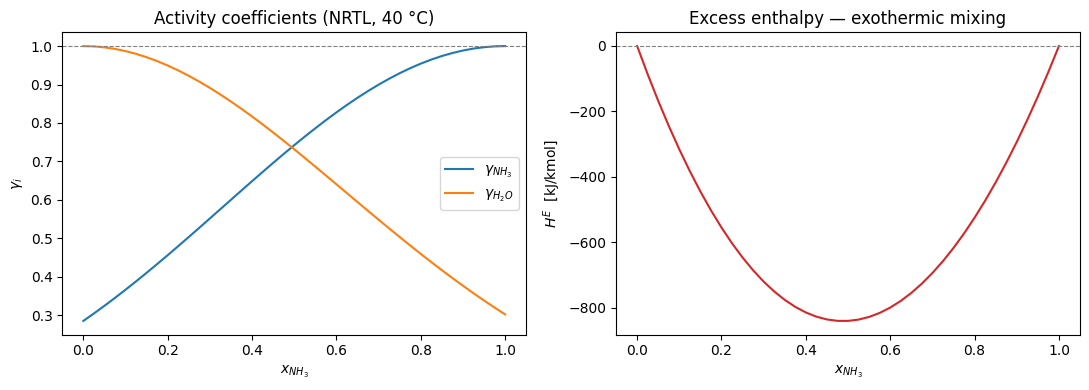

In [3]:
Tk = T.to('K').magnitude
x1 = np.linspace(1e-4, 1 - 1e-4, 41)

def gammas_and_HE(x1v):
    x = [x1v, 1 - x1v]
    g1 = e.activity_ln_gamma(e.ActivityModel.Nrtl, 0, x, AIJ, alpha=ALPHA, t=Tk)
    g2 = e.activity_ln_gamma(e.ActivityModel.Nrtl, 1, x, AIJ, alpha=ALPHA, t=Tk)
    he = e.activity_excess_enthalpy(e.ActivityModel.Nrtl, x, AIJ, alpha=ALPHA, t=Tk)
    return np.exp(g1), np.exp(g2), he

g1, g2, he = np.vectorize(gammas_and_HE)(x1)

fig, (axg, axh) = plt.subplots(1, 2, figsize=(11, 4))
axg.plot(x1, g1, label=r'$\gamma_{NH_3}$')
axg.plot(x1, g2, label=r'$\gamma_{H_2O}$')
axg.axhline(1.0, color='gray', lw=0.8, ls='--')
axg.set_xlabel(r'$x_{NH_3}$'); axg.set_ylabel(r'$\gamma_i$')
axg.set_title('Activity coefficients (NRTL, 40 °C)'); axg.legend()

axh.plot(x1, he, color='C3')
axh.axhline(0.0, color='gray', lw=0.8, ls='--')
axh.set_xlabel(r'$x_{NH_3}$'); axh.set_ylabel(r'$H^E$  [kJ/kmol]')
axh.set_title('Excess enthalpy — exothermic mixing')
fig.tight_layout(); plt.show()

The activity coefficients dip well below 1 and both return to 1 at their pure-component limits; $H^E$ is negative across the whole range and peaks (in magnitude) near equimolar — exactly the exothermic behavior that makes ammonia–water useful as an absorption working pair, and that a temperature-independent model (Margules, van Laar) **cannot** reproduce ($H^E \equiv G^E$ there). Let's pin these facts.

In [4]:
# Numeric checkpoints (a regression here means a real behavioral change).
gm1, gm2, he_mid = gammas_and_HE(0.5)
assert gm1 < 1.0 and gm2 < 1.0, 'NH3-H2O shows negative deviation (gamma<1)'
assert he_mid < 0.0, 'mixing is exothermic (H^E < 0)'
# As x_NH3 -> 0 the *solvent* (water) gamma -> 1 and H^E -> 0; the
# ammonia gamma tends to its (finite, far-from-1) infinite-dilution value.
g1_inf, g2_end, he_end = gammas_and_HE(1e-4)
assert abs(g2_end - 1.0) < 1e-3 and abs(he_end) < 1.0
# Thermodynamic consistency S^E = (H^E - G^E)/T through the wheel.
xm = [0.5, 0.5]
ge = e.activity_excess_gibbs(e.ActivityModel.Nrtl, xm, AIJ, alpha=ALPHA, t=Tk)
se = e.activity_excess_entropy(e.ActivityModel.Nrtl, xm, AIJ, alpha=ALPHA, t=Tk)
assert abs(se - (he_mid - ge) / Tk) < 1e-9
print(f'gamma_NH3(0.5)={gm1:.3f}  gamma_H2O(0.5)={gm2:.3f}  H^E(0.5)={he_mid:.1f} kJ/kmol')

gamma_NH3(0.5)=0.742  gamma_H2O(0.5)=0.732  H^E(0.5)=-839.6 kJ/kmol


### Bubble-pressure curve

Now the same model inside a `System`: the γ-φ bubble pressure of the liquid at 40 °C as a function of ammonia loading. The vapor is nearly pure ammonia even at modest liquid fractions — the reason an ammonia–water absorber can strip ammonia into the vapor so effectively.

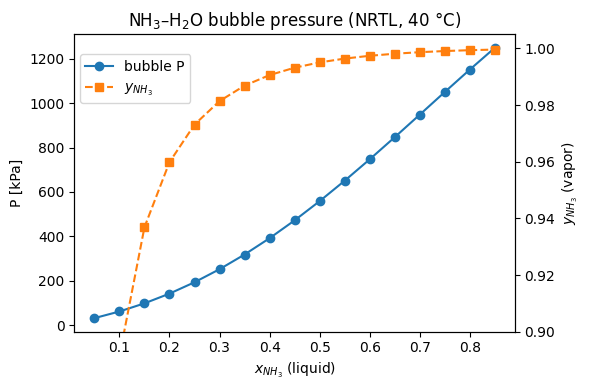

P range: 31 - 1250 kPa


In [5]:
sys = System(['ammonia', 'water'], vapor_model='ideal',
             liquid_model='activity', activity='nrtl', aij=AIJ, alpha=ALPHA)

xs = np.linspace(0.05, 0.85, 17)
P = np.array([sys.bubble_pressure([xi, 1 - xi], T).value for xi in xs])
yNH3 = np.array([sys.bubble_pressure([xi, 1 - xi], T).y[0] for xi in xs])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(xs, P, 'o-', label='bubble P')
ax.set_xlabel(r'$x_{NH_3}$ (liquid)'); ax.set_ylabel('P [kPa]')
ax.set_title('NH$_3$–H$_2$O bubble pressure (NRTL, 40 °C)')
ax2 = ax.twinx(); ax2.plot(xs, yNH3, 's--', color='C1', label=r'$y_{NH_3}$')
ax2.set_ylabel(r'$y_{NH_3}$ (vapor)'); ax2.set_ylim(0.9, 1.005)
fig.legend(loc='upper left', bbox_to_anchor=(0.13, 0.87))
fig.tight_layout(); plt.show()

assert np.all(np.diff(P) > 0), 'bubble P must rise with ammonia loading'
assert np.all(yNH3 > xs), 'vapor is enriched in the volatile ammonia (y > x)'
print(f'P range: {P.min():.0f} - {P.max():.0f} kPa')

> **Accuracy note.** These curves are *qualitatively* correct — the signs, shapes, and limits are right — but the magnitudes depend on the illustrative energies and on an ideal-gas vapor. Ammonia's Antoine correlation is extrapolated above its fitted range here, and the γ-φ path with an ideal vapor loses accuracy as pressure climbs into the MPa range. For quantitative work, regress the NRTL energies against experimental NH₃–H₂O VLE and use a cubic (or reference) vapor. The textbook ammonia–water enthalpy–composition chart is reproduced from reference data downstream in `stages-thermo`, not from this fit.

## Exercises

### Exercise 1 — how much does α matter?

For ammonia mixtures the non-randomness α is unusually influential. Recompute $\gamma_{NH_3}$ at $x_{NH_3}=0.3$ for $\alpha \in \{0.2, 0.3, 0.47\}$ (energies fixed) and report how much the activity coefficient moves.

In [6]:
# TODO: for each a in (0.2, 0.3, 0.47), build ALPHA = [[0,a],[a,0]],
# evaluate ln gamma of NH3 (index 0) at x=[0.3, 0.7], T=Tk, and print
# gamma = exp(ln gamma).


<details><summary>Show solution</summary>

```python
for a in (0.2, 0.3, 0.47):
    al = [[0.0, a], [a, 0.0]]
    lng = e.activity_ln_gamma(e.ActivityModel.Nrtl, 0, [0.3, 0.7], AIJ, alpha=al, t=Tk)
    print(f'alpha={a}:  gamma_NH3 = {np.exp(lng):.4f}')
```

The activity coefficient shifts by several percent across the α range — which is why fixing α = 0.3 out of habit is a poor default for ammonia, and α = 0.2 is recommended instead.
</details>

### Exercise 2 — recover NRTL energies by regression

The engine can fit the two interaction energies to bubble-pressure data (Levenberg–Marquardt, with α held fixed). Generate a synthetic "experimental" dataset from the parameters above, then fit fresh energies back and confirm the fit reproduces the pressures. This is the machinery a real NH₃–H₂O correlation uses — only with measured data.

In [7]:
# TODO: build a list of (T[K], x1, P_exp[kPa]) tuples from sys.bubble_pressure
# at x1 in [0.2, 0.35, 0.5, 0.65, 0.8], then call e.fit_aij_py(...) with
# model=Nrtl, the ammonia/water tcs/pcs/omegas/psat_coeffs, alpha=ALPHA,
# and initial guesses a12_0=a21_0=-500. Inspect the returned rmse.


<details><summary>Show solution</summary>

```python
from vle import components
nh3, h2o = components.get('ammonia'), components.get('water')
data = []
for x1v in (0.2, 0.35, 0.5, 0.65, 0.8):
    P = sys.bubble_pressure([x1v, 1 - x1v], T).value
    data.append((Tk, x1v, P))

a12, a21, sse, rmse, iters = e.fit_aij_py(
    e.ActivityModel.Nrtl,
    [nh3.tc, h2o.tc], [nh3.pc, h2o.pc], [nh3.omega, h2o.omega],
    [list(nh3.psat_coeffs), list(h2o.psat_coeffs)],
    data, -500.0, -500.0, alpha=ALPHA,
)
print(f'fitted g12-g22={a12:.1f}, g21-g11={a21:.1f} kJ/kmol; rmse={rmse:.3e} kPa')
assert rmse < 1.0  # reproduces the synthetic pressures
```

The RMSE collapses to well under 1 kPa — the regressor recovers energies consistent with the data (they need not equal the originals: α-fixed P–x data does not identify the energies uniquely, but it pins the pressures the model predicts).
</details>

## References

- Renon, H.; Prausnitz, J. M. Local Compositions in Thermodynamic Excess Functions for Liquid Mixtures. *AIChE J.* **1968**, *14*, 135. (The NRTL model.)
- Research paper: [Chapter II §2.2 — Activity Coefficient Models](../docs/en/research-paper/chapter-2-vle-theory.md#22-activity-coefficient-models) and [§2.2.1 — Energy Properties](../docs/en/research-paper/chapter-2-vle-theory.md#221-energy-properties-using-activity-coefficient-models) (the excess-property equations 2.44–2.46).
- On α = 0.2 for ammonia mixtures: Junqua, G. *et al.* Reconsideration of the α coefficient in the NRTL model … refrigerant mixtures. *Int. J. Refrig.* **2019**; Zhang, X. *et al.* I&EC Res. **2017**, *56*, 12525.
- Design record: `NRTL_AMMONIA_PLAN.md`; `MODERNIZATION_PLAN.md` Phase 21 (Milestone 14).

**Why this milestone exists:** ammonia–water is the classic absorption working pair, and teaching its enthalpy–composition (Ponchon–Savarit) method downstream needs a liquid model with a real heat of mixing plus ammonia in the database. NRTL supplies both — and lifts the whole aqueous-nonideal ladder (alcohol/acetone–water and the later extractive ternaries), not just this one pair.